Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Created new cavitation initial state
state_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/cavitation_initial.gsd
creation_metadata_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_5.000/center_box/cavitation_creation.hdf5
radius: 5.0
bubble_center: [0. 0. 0.]
particles_removed: 364
N_before: 108000
N_after: 107636
rho_before: 0.7099999529577021
rho_after: 0.7076069901532891
Using GPU device
Final device: <hoomd.device.GPU object at 0x7f044760a210>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rh

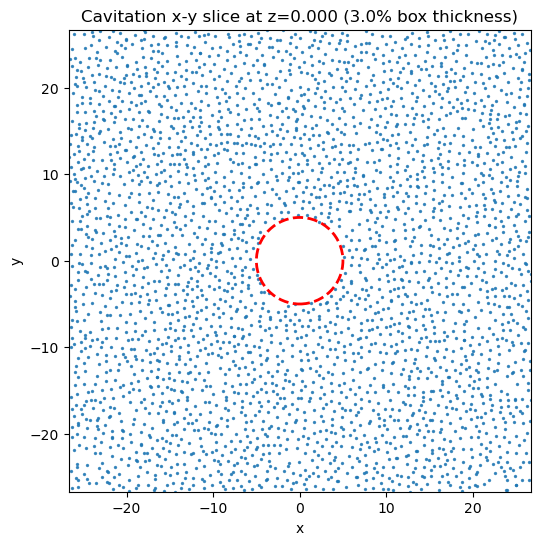

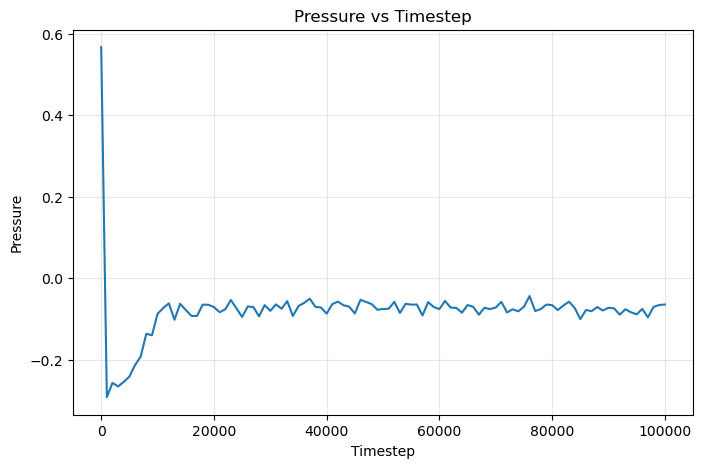

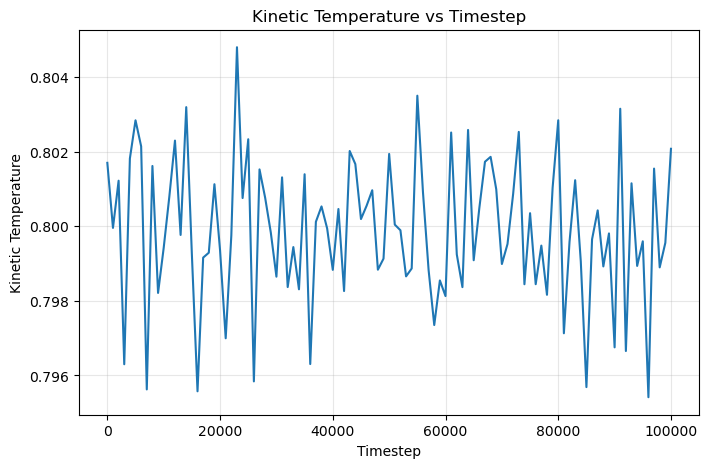

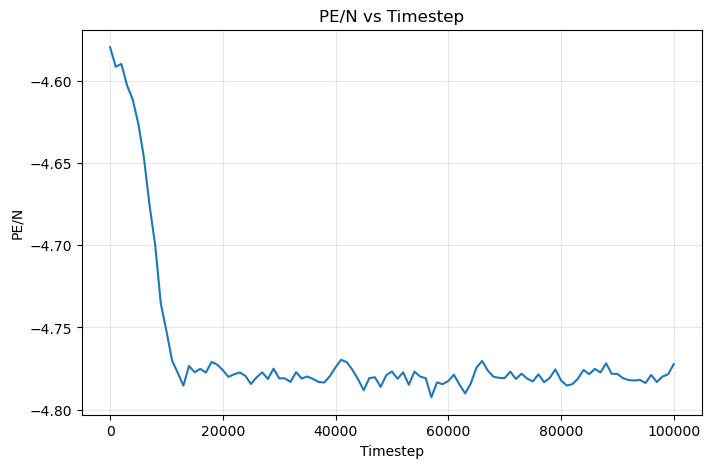

In [24]:
import importlib
from md_Helpers import visualization as vh
importlib.reload(vh)

import importlib
from md_Helpers import cavitation as cav
from md_Helpers import runs

importlib.reload(runs)
importlib.reload(cav)

evolution = cav.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius=5,
    evolve_nsteps=100_000,

    create_source_if_missing=True,
    overwrite_source=False,
    overwrite=False,
)

print("Evolution status:", evolution["status"])
print("Source status:", evolution["initial_result"]["source_result"]["status"])

vh.plot_cavitation_xy_slice(
    evolution["initial_result"],
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

log_path = evolution["paths"]["log_path"]
log = runs.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_temperature")
vh.plot_log_quantity(log, "potential_energy")

In [25]:
from md_Helpers import visualization as vh

trajectory_path = evolution["paths"]["trajectory_path"]
center_z = evolution["initial_result"]["creation_info"].get("bubble_center_z", 0.0)

vh.animate_xy_slice_trajectory(
    trajectory_path,
    fraction=0.03,
    max_frames=100,
    interval=120,
)

In [26]:
from md_Helpers import classification as ps

log_path = evolution["paths"]["log_path"]

voxel_data, metadata_path = ps.read_phase_method_attrs(
    log_path,
    "voxel",
)

print("Metadata:", metadata_path)
print("Phase separated:", voxel_data["phase_separated"])
print("Low-density fraction:", voxel_data["low_density_fraction"])
print(voxel_data)

Metadata: metadata/classification/phase_separation/voxel
Phase separated: True
Low-density fraction: 0.039
{'density_threshold': 0.2, 'low_density_fraction': 0.039, 'max_voxel_density': 0.8414814257276467, 'mean_voxel_density': 0.7076069901532889, 'method': 'voxel_low_density_fraction', 'min_voxel_density': 0.0, 'n_voxels': 1000, 'nbins': 10, 'phase_separated': True, 'std_voxel_density': 0.14539565900903356, 'updated_from_saved_gsd': True, 'voxel_fraction_threshold': 0.01, 'voxel_volume': 152.11268613483145}


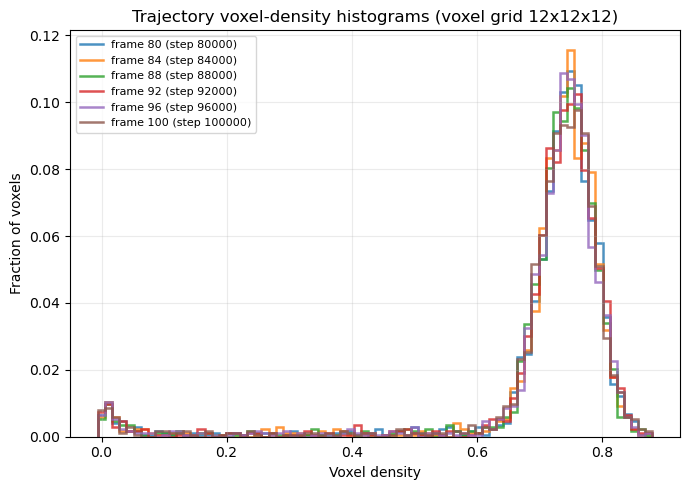

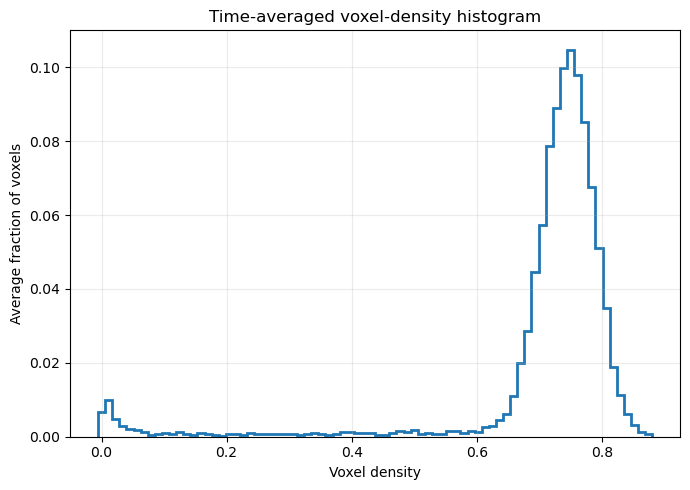

In [27]:
import importlib
from md_Helpers import visualization as vh

importlib.reload(vh)

import numpy as np
import matplotlib.pyplot as plt

voxel_hist = vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=12,
    last_n=6,
    skip=4,
    normalize=True,
)

edges = voxel_hist["density_edges"]

average_hist = np.mean(
    [h["hist_y"] for h in voxel_hist["histograms"]],
    axis=0,
)

plt.figure(figsize=(7, 5))
plt.stairs(average_hist, edges=edges, linewidth=2)

plt.xlabel("Voxel density")
plt.ylabel("Average fraction of voxels")
plt.title("Time-averaged voxel-density histogram")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

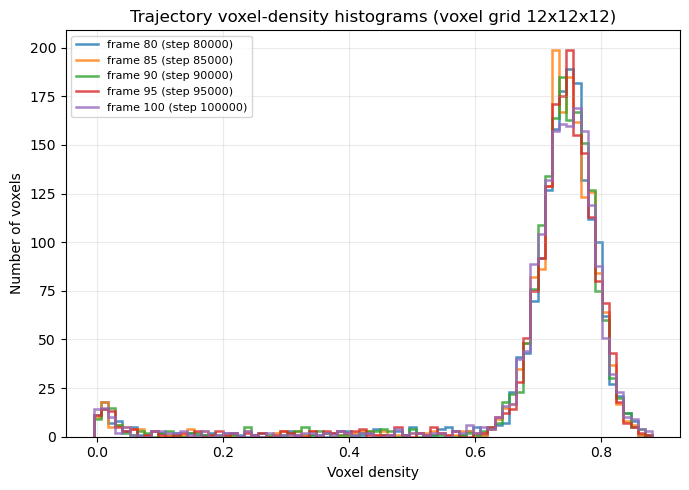

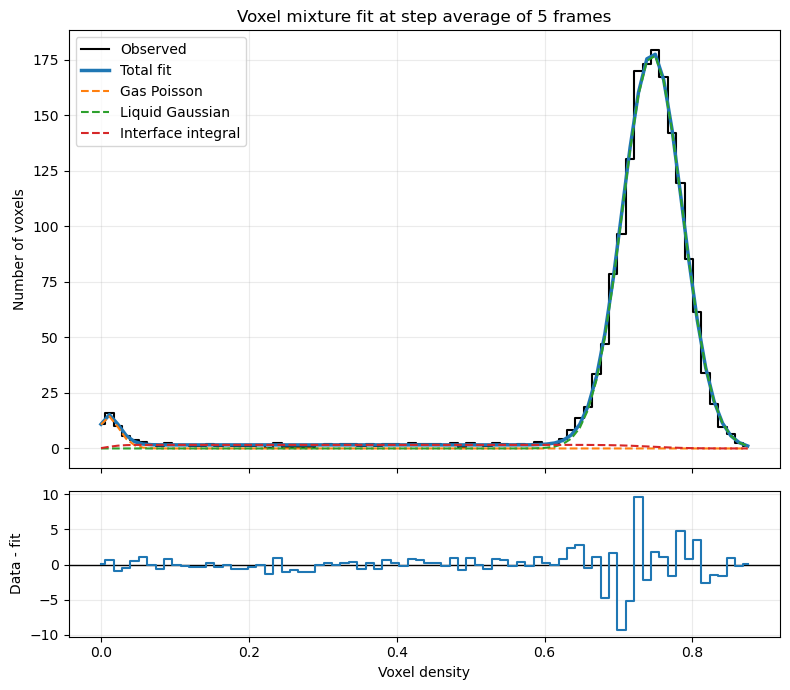

Gas density: 0.01524826224706509
Liquid density: 0.7459123171272465
Gas fraction: 0.023815002803090127
Interface fraction: 0.059856926848985914
Liquid fraction: 0.9163280703479239
Fit successful: True


In [35]:
import numpy as np
from md_Helpers import voxel_fit as vf

nbins = 12

voxel_hist = vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=nbins,
    last_n=5,
    skip=5,
    normalize=False,
)

# Histogram matrix: one row per selected frame
hist_matrix = np.stack([
    item["hist_y"]
    for item in voxel_hist["histograms"]
])

edges = voxel_hist["density_edges"]
n_frames = hist_matrix.shape[0]

# Recover particle counts represented by each density bin
voxel_volume = 1.0 / np.diff(edges)[0]
density_centers = 0.5 * (edges[:-1] + edges[1:])
particle_counts = np.rint(
    density_centers * voxel_volume
).astype(int)

# Pool all selected frames for a statistically cleaner fit
pooled_bin_counts = hist_matrix.sum(axis=0).astype(int)
pooled_voxel_counts = np.repeat(
    particle_counts,
    pooled_bin_counts,
)

fit = vf.fit_voxel_count_mixture(
    pooled_voxel_counts,
    voxel_volume=voxel_volume,
)

# Convert pooled totals into counts for one average frame
average_fit = fit.copy()

for key in [
    "observed_counts",
    "model_counts",
    "gas_counts",
    "liquid_counts",
    "interface_counts",
]:
    average_fit[key] = fit[key] / n_frames

average_fit["timestep"] = f"average of {n_frames} frames"

vh.plot_voxel_mixture_fit(
    average_fit,
    x_axis="density",
)

print("Gas density:", fit["gas_density"])
print("Liquid density:", fit["liquid_density"])
print("Gas fraction:", fit["gas_weight"])
print("Interface fraction:", fit["interface_weight"])
print("Liquid fraction:", fit["liquid_weight"])
print("Fit successful:", fit["success"])

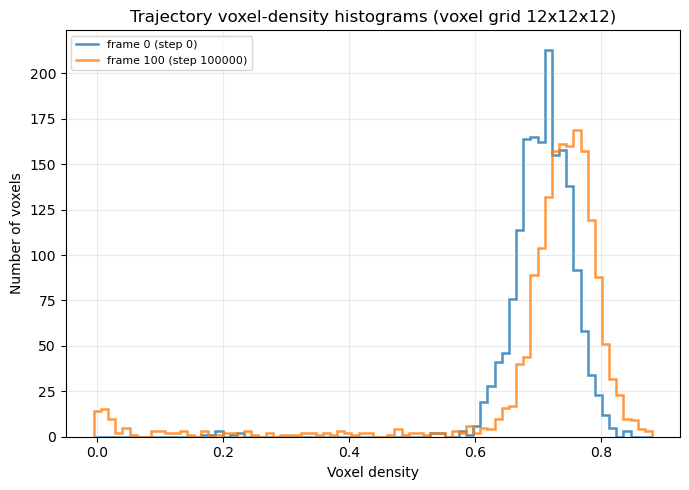

In [33]:
vh.plot_trajectory_voxel_histograms(
    evolution,
    nbins=12,
    frame_indices=[0,-1],
);

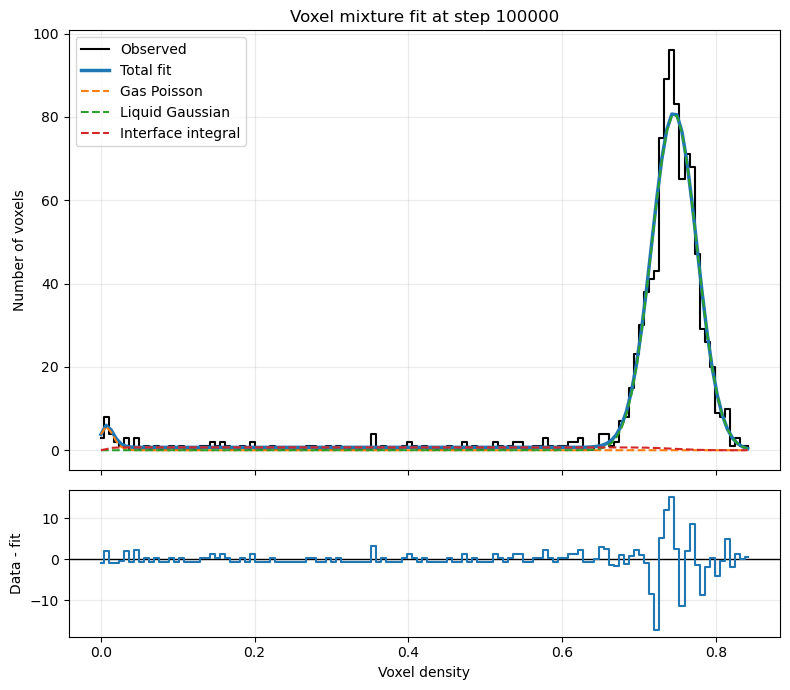

In [30]:
import importlib
from md_Helpers import voxel_fit as vf
from md_Helpers import visualization as vh

importlib.reload(vf)
importlib.reload(vh)

voxel_fit = vf.fit_last_frame_voxel_histogram(
    evolution=evolution,
    frame_index=-1,
    voxel_nbins=10,
    interface_points=40,
    max_iterations=500,
)

vh.plot_voxel_mixture_fit(
    voxel_fit,
    x_axis="density",
    show_residuals=True,
)

In [31]:
print("Fit successful:", voxel_fit["success"])
print("Message:", voxel_fit["message"])

print("\nDensities")
print("Gas density:", voxel_fit["gas_density"])
print("Liquid density:", voxel_fit["liquid_density"])
print("Liquid width:", voxel_fit["liquid_sigma_density"])

print("\nVoxel fractions")
print("Gas:", voxel_fit["gas_weight"])
print("Liquid:", voxel_fit["liquid_weight"])
print("Interface:", voxel_fit["interface_weight"])

print("\nModel comparison")
print("AIC:", voxel_fit["AIC"])
print("BIC:", voxel_fit["BIC"])

Fit successful: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Densities
Gas density: 0.00992254660265218
Liquid density: 0.7459506810271117
Liquid width: 0.029351914341926896

Voxel fractions
Gas: 0.017148607843463032
Liquid: 0.9059114540665439
Interface: 0.07693993808999286

Model comparison
AIC: 6687.896605846289
BIC: 6712.4353822412
